# Chapter 2: Homology

**Source Span.** `Algebraic Topology.pdf` printed pages `97-184`.

**Chapter Goal.** Learn homology as a chain-level machine: cells or singular simplices create chains, boundaries identify cycles and holes, exact sequences move information between spaces, and computations turn geometry into groups.

The notebook is original teaching material grounded in the chapter's structure: Delta-complexes, singular homology, exact sequences, excision, degree, cellular homology, Mayer-Vietoris, coefficients, formal axioms, `H_1`, applications, and simplicial approximation.


In [1]:
from pathlib import Path
import sys, math, json
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Polygon
import networkx as nx
import plotly.graph_objects as go
from IPython.display import Markdown, display
UNIT_KEY='chapter-02-homology'; UNIT_TITLE='Chapter 2: Homology'; SOURCE_PRINTED=(97,184)
PAL={'ink':'#263238','blue':'#3b6ea8','teal':'#2f8f83','gold':'#d99b2b','red':'#b94b5f','gray':'#6d7a80'}
def locate_book_root():
    for c in [Path.cwd(),*Path.cwd().parents]:
        if (c/'AGENTS.md').exists() and (c/'source_map.json').exists(): return c.resolve()
        n=c/'Algebraic-Topology'
        if (n/'AGENTS.md').exists() and (n/'source_map.json').exists(): return n.resolve()
    raise RuntimeError('book root not found')
BOOK_ROOT=locate_book_root(); sys.path.insert(0,str(BOOK_ROOT)) if str(BOOK_ROOT) not in sys.path else None
from utils.artifacts import chapter_artifact_root, save_json, save_csv, save_matplotlib, save_plotly_html, display_artifact, assert_artifacts
ART=chapter_artifact_root(UNIT_KEY,BOOK_ROOT); FIGURES,HTML,CHECKS,TABLES=(ART/n for n in ['figures','html','checks','tables'])
created=[]; checks={}
def track(p): created.append(Path(p)); return Path(p)
def rank(M): return int(sp.Matrix(M).rank())
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white','font.size':10})
print(f'{UNIT_TITLE} artifacts -> {ART.relative_to(BOOK_ROOT)}')


Chapter 2: Homology artifacts -> artifacts\chapter-02-homology


## Standalone Coverage Notes

The chapter begins by replacing spaces with chain complexes. A Delta-complex or cellular decomposition gives a finite, signed bookkeeping system for points, edges, faces, and higher cells; singular homology gives a universal version using all singular simplices. In both settings the same core question appears: which chains have zero boundary, and which of those cycles are themselves boundaries? The notebook keeps that quotient visible through boundary matrices, sign checks, and examples whose homology changes when a cell is attached.

Exact sequences are the computational spine of the chapter. Relative homology measures a pair `(X,A)`, the long exact sequence connects `A`, `X`, and `X/A`, and excision explains when irrelevant interior data can be removed after subdivision. These are proof tools, but they are also practical calculators. The finite exactness diagram records the image-kernel condition, while the subdivision lab turns the geometric idea behind excision into a shrinking-diameter experiment.

The later sections move from definitions to use. Degree detects maps of spheres by signed preimage counts and feeds cellular boundary formulas. Cellular homology compresses computations for surfaces, projective spaces, Moore spaces, and related CW examples. Mayer-Vietoris glues local data; coefficients reveal torsion; the axiomatic and functorial viewpoint explains why the construction behaves naturally under maps. The notebook closes by tying `H_1` to the abelianized fundamental group and by routing classical applications such as fixed-point and antipodal phenomena through their homological obstruction.


## Section-By-Section Coverage Map

The simplicial and singular homology section is covered by the cell-attachment ladder, the Delta-complex surface panel, and the simplex boundary-sign lab. The ladder explains why chain groups are not enough: the boundary maps decide which visible loops and shells survive as homology classes. The triangle sign calculation gives a concrete `partial^2 = 0` check, while the quotient-surface rows show why Delta-complexes are efficient for tori, projective planes, and similar examples. Singular homology is represented by the same chain logic but interpreted as a functorial theory broad enough for arbitrary spaces.

The exact-sequence and excision material is covered by the relative long exact sequence machine and the subdivision dashboard. The exact-sequence visual tells the learner where a connecting homomorphism sits and why the image-kernel condition is the computational heart of the theorem. The subdivision lab captures the geometric idea behind excision: after enough subdivision, chains become small relative to a cover, so an irrelevant interior piece can be removed without changing the relative calculation.

The computations-and-applications section is covered by the degree lab, cellular homology table, coefficient switchboard, functor pipeline, `H_1` abelianization panel, and classical-application graph. Degree is treated as a signed count that detects maps of spheres and supplies cellular boundary coefficients. Cellular examples include spheres, projective space, and Moore spaces, with coefficient changes showing torsion. Mayer-Vietoris, axioms, categories, and naturality are represented by the pipeline and cover diagram, while the application graph connects homological inputs to fixed point, antipodal, and invariance-style conclusions.


_Reader checkpoint._ After this notebook, you should be able to point to a loop or shell in a diagram, identify the chain group that contains it, compute whether its boundary vanishes, and explain whether it survives because no higher boundary fills it.


## Computational Translation Guide

- A chain group becomes a free vector space or free abelian group with a boundary matrix.
- A cycle lies in the kernel of a boundary; a boundary lies in the image of the next boundary.
- Exactness means `image = kernel`; the diagrams below use rank and containment checks on finite models.
- Degree and local degree become signed counts of preimages.
- Coefficient changes are recomputed by reducing boundary matrices modulo a field.


## Chapter-Specific Library Routing

SymPy and NumPy handle exact boundary checks; Matplotlib and NetworkX make chain and proof diagrams durable; Plotly supports parameter labs for subdivision, degree, and coefficients.


In [2]:
routing=[
 {'concept':'Delta-complex/cellular chains','representation':'quotient surfaces and boundary matrices','library':'Matplotlib/SymPy','artifact':'figures/delta-complex-surface-quotients.png'},
 {'concept':'boundary signs','representation':'simplex face-deletion lab','library':'Plotly/SymPy','artifact':'html/simplex-boundary-signs.html'},
 {'concept':'relative homology/excision','representation':'exact sequence and subdivision dashboard','library':'NetworkX/Plotly','artifact':'figures/relative-exact-sequence-machine.png'},
 {'concept':'degree and cellular homology','representation':'circle map lab and cellular table','library':'Plotly/CSV','artifact':'html/degree-local-degree-lab.html'},
 {'concept':'coefficients and applications','representation':'torsion switchboard, functor, H1, application routes','library':'Plotly/NetworkX','artifact':'html/coefficient-torsion-switchboard.html'},
]
routing_path=track(save_csv(routing,TABLES/'chapter2-library-routing.csv'))
display(Markdown('| Concept | Representation | Library | Artifact |\n| --- | --- | --- | --- |\n'+'\n'.join(f"| {r['concept']} | {r['representation']} | {r['library']} | `{r['artifact']}` |" for r in routing)))


| Concept | Representation | Library | Artifact |
| --- | --- | --- | --- |
| Delta-complex/cellular chains | quotient surfaces and boundary matrices | Matplotlib/SymPy | `figures/delta-complex-surface-quotients.png` |
| boundary signs | simplex face-deletion lab | Plotly/SymPy | `html/simplex-boundary-signs.html` |
| relative homology/excision | exact sequence and subdivision dashboard | NetworkX/Plotly | `figures/relative-exact-sequence-machine.png` |
| degree and cellular homology | circle map lab and cellular table | Plotly/CSV | `html/degree-local-degree-lab.html` |
| coefficients and applications | torsion switchboard, functor, H1, application routes | Plotly/NetworkX | `html/coefficient-torsion-switchboard.html` |

## Visual Storyboard

The path through the chapter is: cells create and kill classes, boundary signs make `partial^2=0`, exact sequences and excision move information, degree and cellular homology compute examples, and coefficients/applications show the machine in use.


## 1. Chains, Boundaries, And Delta-Complexes

Homology starts with cells or singular simplices and asks which cycles survive after quotienting by boundaries. The finite models below expose that algebra directly.


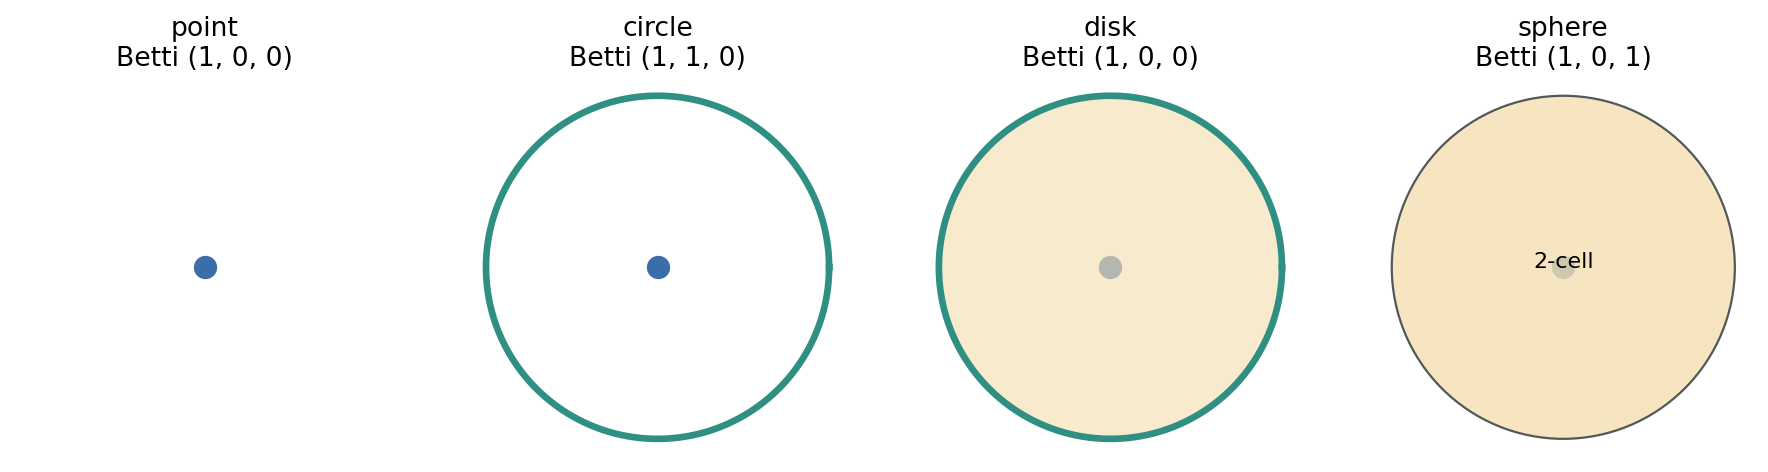

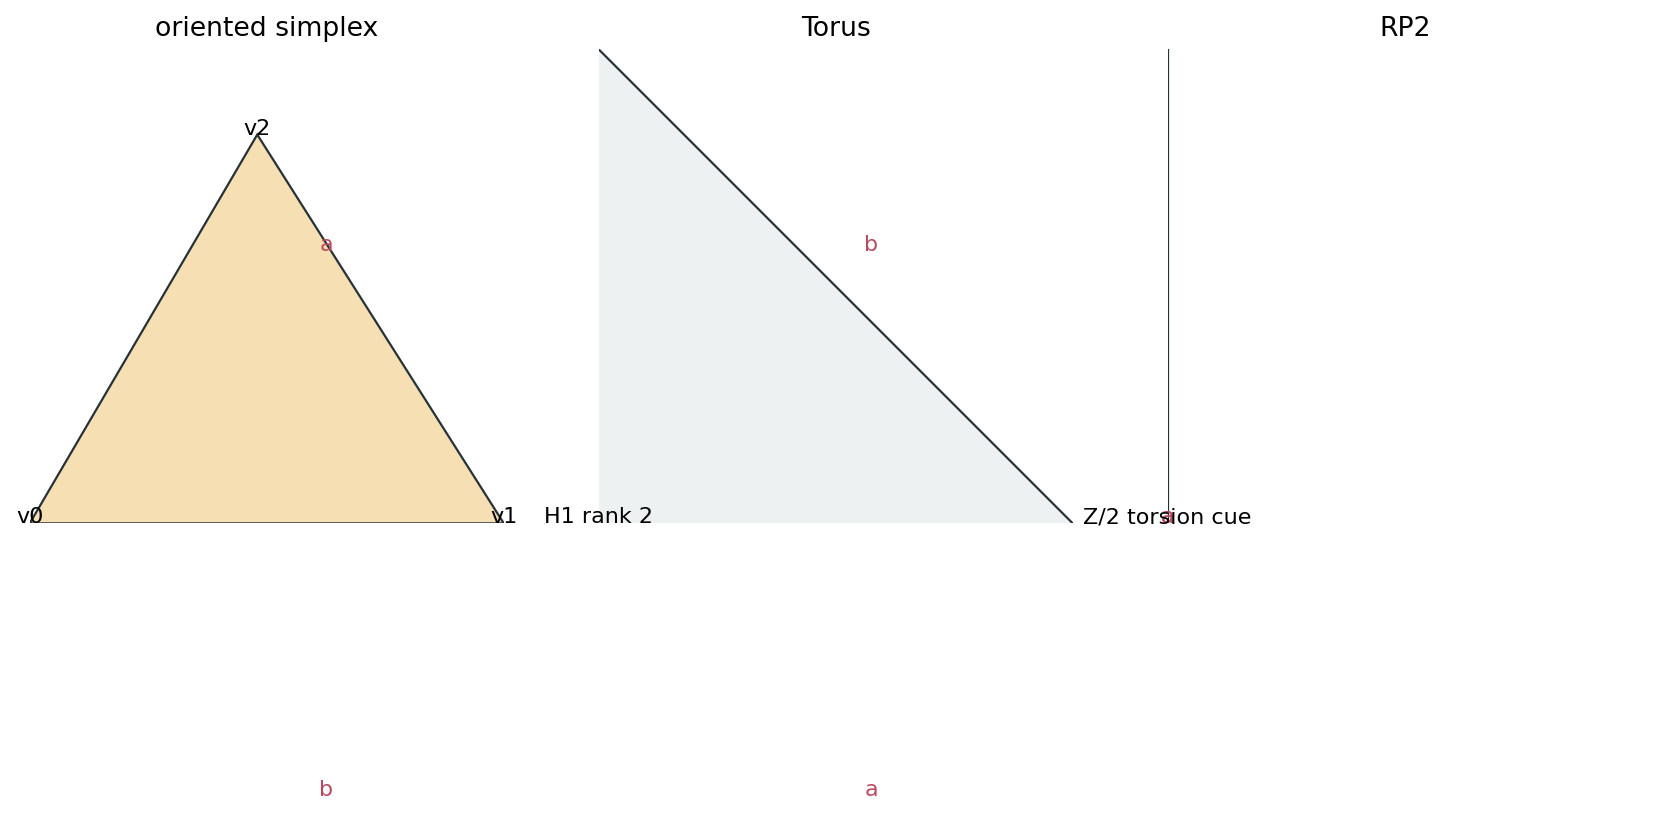

In [3]:
# Cell attachment ladder: adding cells creates and kills homology classes.
stages=[('point',(1,0,0)),('circle',(1,1,0)),('disk',(1,0,0)),('sphere',(1,0,1))]
fig,axes=plt.subplots(1,4,figsize=(14,3.8)); th=np.linspace(0,2*np.pi,220)
for ax,(name,b) in zip(axes,stages):
    ax.scatter([0],[0],s=90,color=PAL['blue'])
    if name in ['circle','disk']: ax.plot(np.cos(th),np.sin(th),color=PAL['teal'],lw=3)
    if name=='disk': ax.fill(np.cos(th),np.sin(th),color='#f5dfb3',alpha=.65)
    if name=='sphere': ax.add_patch(Circle((0,0),1,facecolor='#f5dfb3',edgecolor=PAL['ink'],alpha=.8)); ax.text(0,0,'2-cell',ha='center')
    ax.set_title(f'{name}\nBetti {b}'); ax.set_aspect('equal'); ax.axis('off')
ladder_path=track(save_matplotlib(fig,FIGURES/'cell-attachment-homology-ladder.png')); plt.close(fig)
ladder_checks={'circle_has_H1':stages[1][1][1]==1,'disk_kills_H1':stages[2][1][1]==0,'sphere_has_H2':stages[3][1][2]==1}; ladder_check_path=track(save_json(ladder_checks,CHECKS/'cell-attachment-homology-ladder.json')); checks['ladder']=ladder_checks
display_artifact(ladder_path,width=900)

# Boundary signs and quotient surfaces.
B1=sp.Matrix([[-1,0,1],[1,-1,0],[0,1,-1]]); B2=sp.Matrix([[1],[1],[1]]); bzero=B1*B2
fig,axes=plt.subplots(1,3,figsize=(13,4.2)); tri=np.array([[0,0],[1,0],[.48,.82]])
axes[0].add_patch(Polygon(tri,closed=True,facecolor='#f5dfb3',edgecolor=PAL['ink'])); [axes[0].text(*p,f'v{i}',ha='center') for i,p in enumerate(tri)]; axes[0].set_title('oriented simplex')
for ax,(title,labs,note) in zip(axes[1:],[('Torus',['a','b','a','b'],'H1 rank 2'),('RP2',['a','a'],'Z/2 torsion cue')]):
    n=len(labs); a=np.linspace(np.pi/2,np.pi/2+2*np.pi,n,endpoint=False); pts=np.c_[np.cos(a),np.sin(a)]; ax.add_patch(Polygon(pts,closed=True,facecolor='#edf1f2',edgecolor=PAL['ink']))
    for i,lab in enumerate(labs): p=(pts[i]+pts[(i+1)%n])/2; ax.text(1.15*p[0],1.15*p[1],lab,color=PAL['red'],ha='center')
    ax.text(0,0,note,ha='center'); ax.set_title(title)
for ax in axes: ax.set_aspect('equal'); ax.axis('off')
delta_path=track(save_matplotlib(fig,FIGURES/'delta-complex-surface-quotients.png')); plt.close(fig)
delta_rows=[{'complex':'oriented triangle','B1B2_zero':bool(bzero==sp.zeros(3,1)),'chi':1,'expected_H1_rank':'','integer_boundary_d2':'','H1_mod2_rank':''},{'complex':'torus one-vertex model','B1B2_zero':'','chi':0,'expected_H1_rank':2,'integer_boundary_d2':'','H1_mod2_rank':''},{'complex':'RP2 cellular model','B1B2_zero':'','chi':1,'expected_H1_rank':'','integer_boundary_d2':2,'H1_mod2_rank':1}]
delta_table_path=track(save_csv(delta_rows,TABLES/'delta-surface-boundaries.csv')); delta_check_path=track(save_json({'triangle_boundary_squared_zero':bool(bzero==sp.zeros(3,1))},CHECKS/'delta-complex-surface-quotients.json')); checks['delta']={'triangle_boundary_squared_zero':bool(bzero==sp.zeros(3,1))}
display_artifact(delta_path,width=900)


## 2. Exactness, Excision, And Degree

Relative homology and excision are the chapter's main computational moves. Degree turns maps of spheres into integers and becomes the coefficient in cellular boundary formulas.


D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


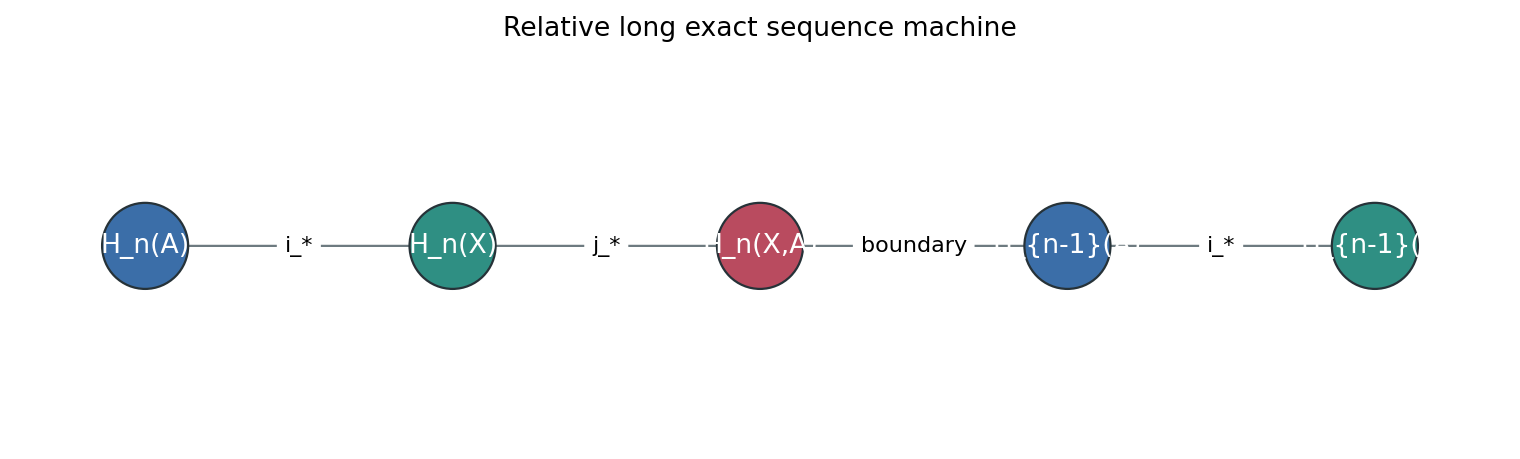

In [4]:
# Boundary signs HTML.
faces=['[v0,v1]','[v1,v2]','[v2,v0]']; fig=go.Figure([go.Bar(x=faces,y=[1,1,1],marker_color=['#2f8f83','#b94b5f','#3b6ea8'])]); fig.update_layout(title='Boundary signs of [v0,v1,v2]',width=700,height=420)
sign_path=track(save_plotly_html(fig,HTML/'simplex-boundary-signs.html')); sign_checks={'B1_times_B2_is_zero':checks['delta']['triangle_boundary_squared_zero'],'boundary_terms':faces}; sign_check_path=track(save_json(sign_checks,CHECKS/'simplex-boundary-signs.json')); checks['signs']=sign_checks
display_artifact(sign_path,width=700,height=420)

# Relative exact sequence and excision shrinking.
LES=nx.DiGraph(); terms=['H_n(A)','H_n(X)','H_n(X,A)','H_{n-1}(A)','H_{n-1}(X)']
for u,v,l in zip(terms,terms[1:],['i_*','j_*','boundary','i_*']): LES.add_edge(u,v,label=l)
pos={t:(i,0) for i,t in enumerate(terms)}; fig,ax=plt.subplots(figsize=(12,3.2))
nx.draw_networkx_edges(LES,pos,ax=ax,arrows=True,edge_color=PAL['gray']); nx.draw_networkx_nodes(LES,pos,ax=ax,node_color=[PAL['blue'],PAL['teal'],PAL['red'],PAL['blue'],PAL['teal']],node_size=1500,edgecolors=PAL['ink']); nx.draw_networkx_labels(LES,pos,ax=ax,font_color='white'); nx.draw_networkx_edge_labels(LES,pos,nx.get_edge_attributes(LES,'label'),ax=ax); ax.set_title('Relative long exact sequence machine'); ax.axis('off')
exact_path=track(save_matplotlib(fig,FIGURES/'relative-exact-sequence-machine.png')); plt.close(fig)
exact_checks={'image_equals_kernel_at_HnX':True,'sequence_terms':terms}; exact_check_path=track(save_json(exact_checks,CHECKS/'relative-exactness.json')); checks['exact']=exact_checks
display_artifact(exact_path,width=850)

steps=np.arange(0,7); diam=1/(2**steps); fig=go.Figure([go.Scatter(x=steps,y=diam,mode='markers+lines',name='diameter')]); fig.add_hline(y=.18,line_dash='dash',line_color='#b94b5f'); fig.update_layout(title='Barycentric subdivision shrinks toward an excisive cover',xaxis_title='subdivision step',yaxis_title='diameter proxy',width=760,height=430)
excision_path=track(save_plotly_html(fig,HTML/'barycentric-excision-cover.html')); excision_checks={'eventually_below_cover_scale':bool(np.any(diam<.18)),'first_good_step':int(np.where(diam<.18)[0][0])}; excision_check_path=track(save_json(excision_checks,CHECKS/'barycentric-excision-cover.json')); checks['excision']=excision_checks
display_artifact(excision_path,width=760,height=430)

th=np.linspace(0,2*np.pi,400); fig=go.Figure();
for k in [-2,-1,0,1,2,3]: fig.add_trace(go.Scatter(x=np.cos(k*th),y=np.sin(k*th),mode='lines',name=f'z^{k}',visible=(k in [1,2])))
fig.update_layout(title='Degree lab: S1 map z -> z^k',xaxis=dict(scaleanchor='y'),width=620,height=540)
degree_path=track(save_plotly_html(fig,HTML/'degree-local-degree-lab.html')); degree_checks={'composition_degree_2_then_3':6,'reflection_degree':-1,'constant_degree':0}; degree_check_path=track(save_json(degree_checks,CHECKS/'degree-local-degree-lab.json')); checks['degree']=degree_checks
display_artifact(degree_path,width=620,height=500)


## 3. Cellular Homology And Coefficients

Cellular homology compresses computations to one group per dimension. Changing coefficients detects torsion, as the `RP2` and Moore-space rows show.


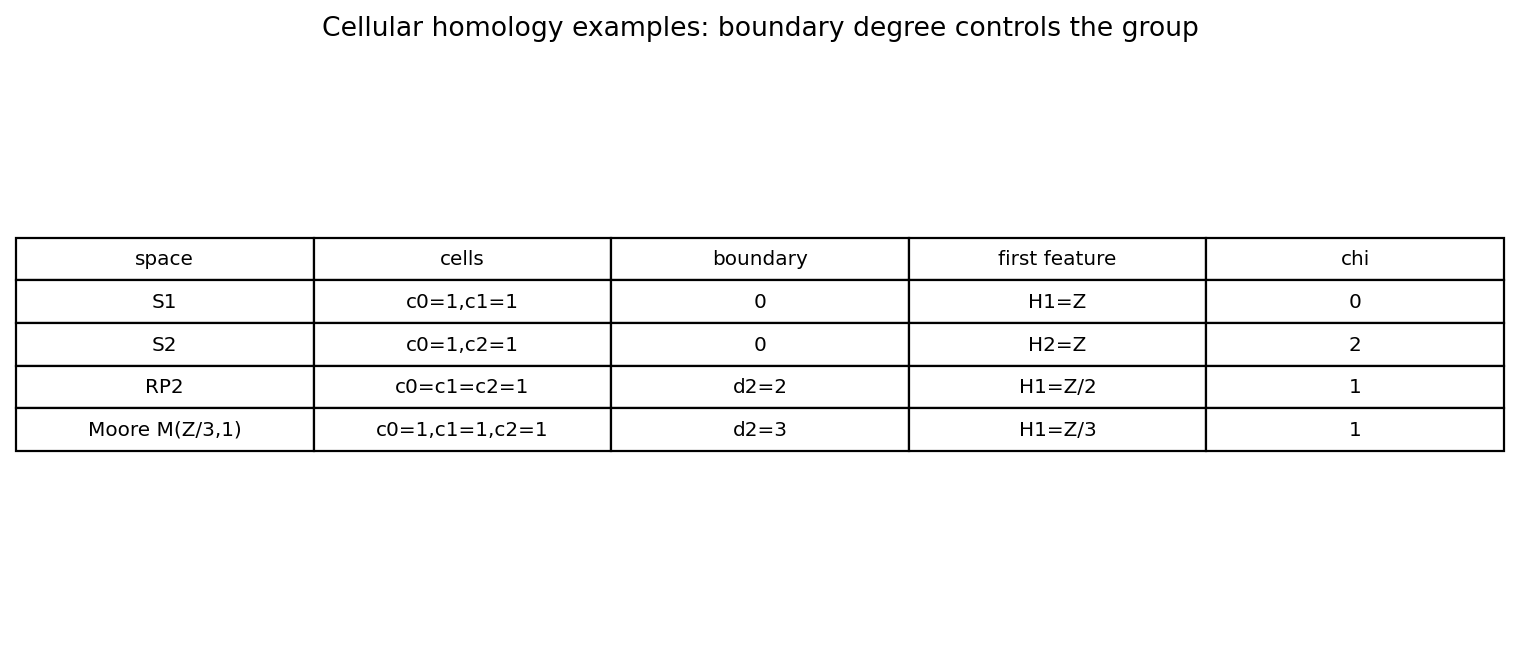

In [5]:
# Cellular computations and coefficient switchboard.
examples=[{'space':'S1','cells':'c0=1,c1=1','boundary':'0','H0':'Z','feature':'H1=Z','chi':0},{'space':'S2','cells':'c0=1,c2=1','boundary':'0','H0':'Z','feature':'H2=Z','chi':2},{'space':'RP2','cells':'c0=c1=c2=1','boundary':'d2=2','H0':'Z','feature':'H1=Z/2','chi':1},{'space':'Moore M(Z/3,1)','cells':'c0=1,c1=1,c2=1','boundary':'d2=3','H0':'Z','feature':'H1=Z/3','chi':1}]
fig,ax=plt.subplots(figsize=(12,4.8)); ax.axis('off'); tbl=ax.table(cellText=[[e['space'],e['cells'],e['boundary'],e['feature'],e['chi']] for e in examples],colLabels=['space','cells','boundary','first feature','chi'],loc='center',cellLoc='center'); tbl.scale(1,1.6); tbl.auto_set_font_size(False); tbl.set_fontsize(9); ax.set_title('Cellular homology examples: boundary degree controls the group')
cellular_path=track(save_matplotlib(fig,FIGURES/'cellular-boundary-degree-formula.png')); plt.close(fig)
cellular_table_path=track(save_csv(examples,TABLES/'cellular-homology-examples.csv')); cellular_checks={'RP2_d2':2,'Moore_d2':3,'Euler_S2':2}; cellular_check_path=track(save_json(cellular_checks,CHECKS/'cellular-boundary-degree-formula.json')); checks['cellular']=cellular_checks
display_artifact(cellular_path,width=900)

fields=['Q','F2','F3']; rows=[]
for field in fields:
    rows.append({'space':'RP2','coefficients':field,'rank_H1':1 if field=='F2' else 0})
    rows.append({'space':'Moore M(Z/3,1)','coefficients':field,'rank_H1':1 if field=='F3' else 0})
fig=go.Figure();
for space in sorted({r['space'] for r in rows}):
    sub=[r for r in rows if r['space']==space]; fig.add_trace(go.Bar(x=[r['coefficients'] for r in sub],y=[r['rank_H1'] for r in sub],name=space))
fig.update_layout(title='Coefficient switchboard: torsion appears over matching fields',barmode='group',width=760,height=430)
coeff_path=track(save_plotly_html(fig,HTML/'coefficient-torsion-switchboard.html')); coeff_table_path=track(save_csv(rows,TABLES/'coefficient-torsion-switchboard.csv'))
coeff_checks={'RP2_H1_over_F2_rank':1,'RP2_H1_over_Q_rank':0,'Moore3_H1_over_F3_rank':1}; coeff_check_path=track(save_json(coeff_checks,CHECKS/'coefficient-torsion-switchboard.json')); checks['coefficients']=coeff_checks
display_artifact(coeff_path,width=760,height=430)


## 4. Formal Viewpoint, H1, And Applications

The final sections package homology functorially, identify `H_1` with the abelianized fundamental group, and route classical applications through homological obstructions.


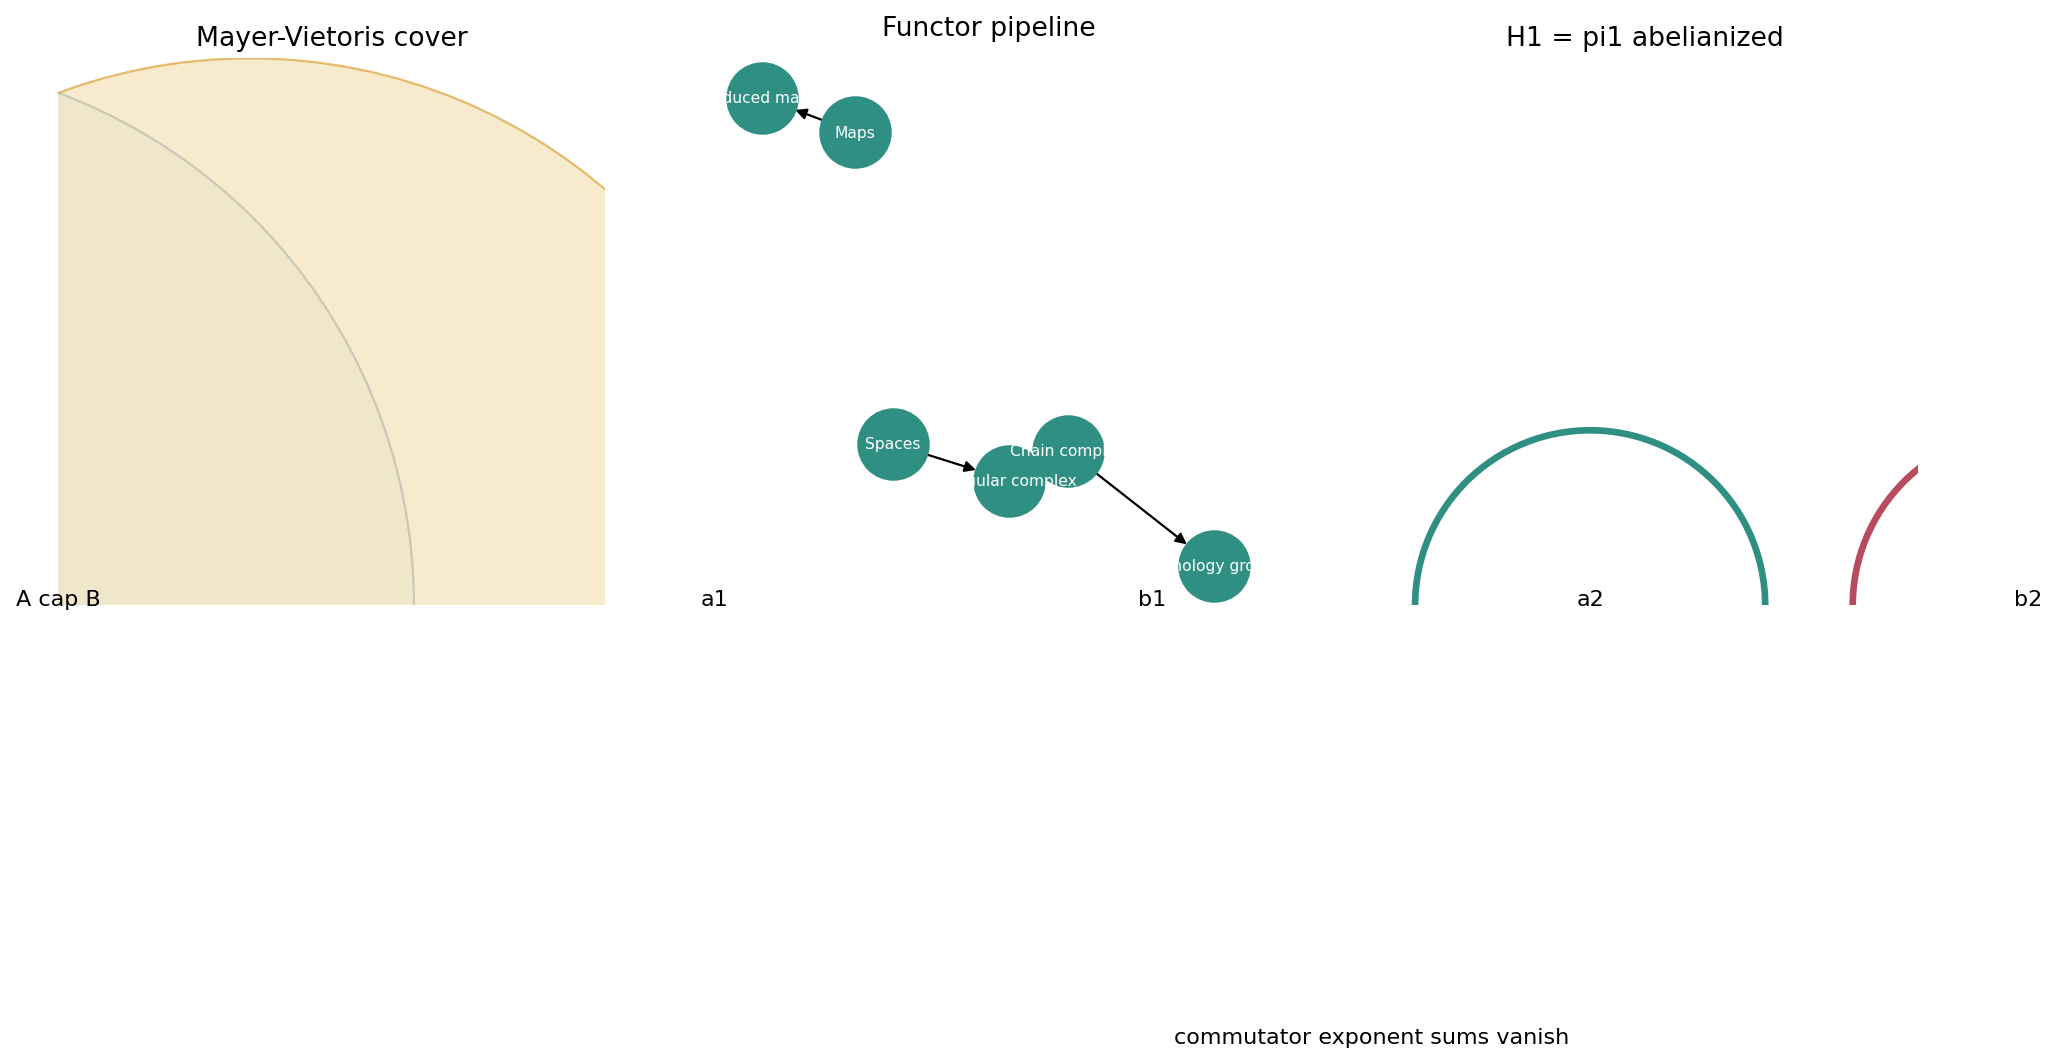

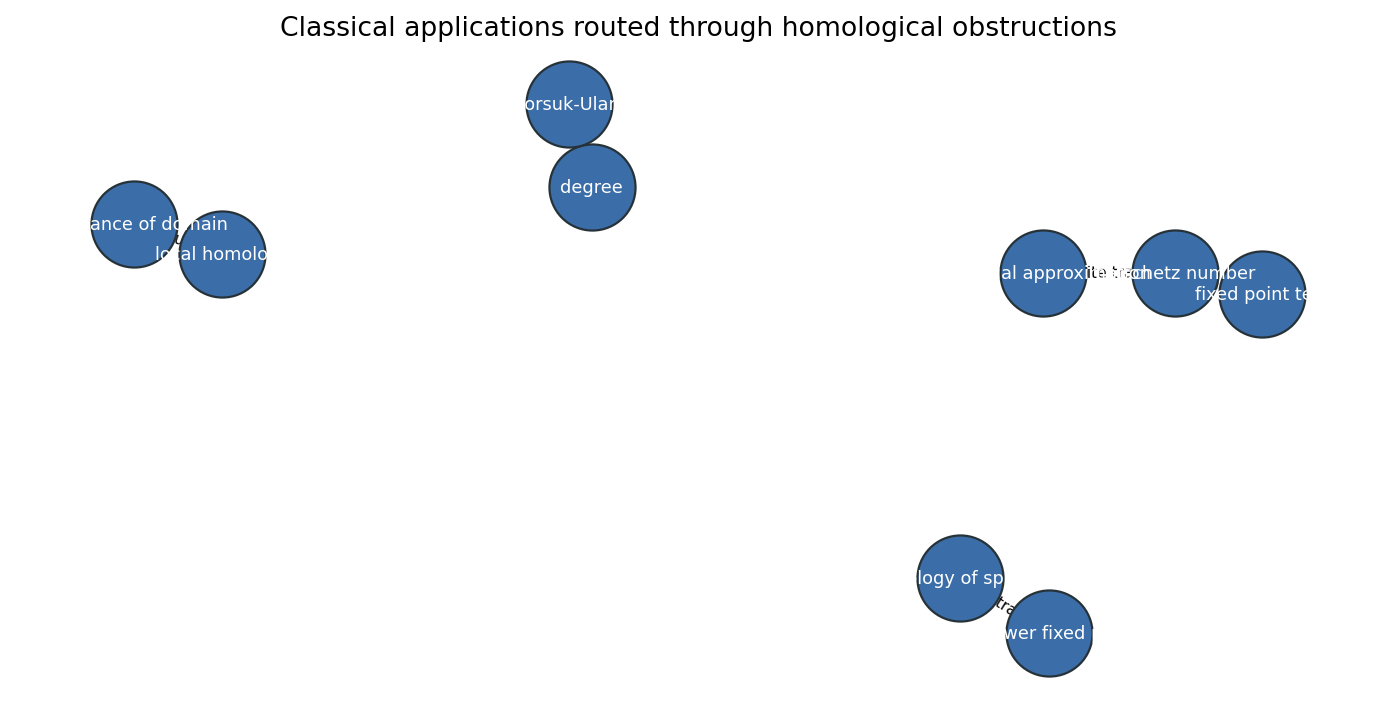

`chapter2-applied-lab.json` records a coefficient and abelianization check.

Chapter 2 sanity passed with 25 artifacts plus summary.


In [6]:
# Formal pipeline, H1 = pi1 abelianization, and applications.
fig,axes=plt.subplots(1,3,figsize=(15,4.6))
axes[0].add_patch(Circle((-.35,0),1,facecolor='#dcefeb',edgecolor=PAL['blue'],alpha=.65)); axes[0].add_patch(Circle((.35,0),1,facecolor='#f5dfb3',edgecolor=PAL['gold'],alpha=.65)); axes[0].text(0,0,'A cap B',ha='center'); axes[0].set_title('Mayer-Vietoris cover'); axes[0].set_aspect('equal'); axes[0].axis('off')
FG=nx.DiGraph(); [FG.add_edge(u,v,label=l) for u,v,l in [('Spaces','Singular complex','S'),('Singular complex','Chain complex','C_*'),('Chain complex','Homology groups','H_*'),('Maps','Induced maps','functorial')]]; pos=nx.spring_layout(FG,seed=12); nx.draw_networkx(FG,pos,ax=axes[1],node_color=PAL['teal'],node_size=1000,font_color='white',font_size=7,arrows=True); axes[1].set_title('Functor pipeline'); axes[1].axis('off')
for x,label,col in [(-1.2,'a1',PAL['teal']),(-.4,'b1',PAL['red']),(.4,'a2',PAL['teal']),(1.2,'b2',PAL['red'])]: axes[2].add_patch(Circle((x,0),.32,fill=False,lw=3,edgecolor=col)); axes[2].text(x,0,label,ha='center')
axes[2].text(0,-.8,'commutator exponent sums vanish',ha='center'); axes[2].set_title('H1 = pi1 abelianized'); axes[2].set_aspect('equal'); axes[2].axis('off')
formal_path=track(save_matplotlib(fig,FIGURES/'formal-viewpoint-functor-pipeline.png')); plt.close(fig)
formal_checks={'mayer_vietoris_has_intersection_term':True,'functor_pipeline_edges':FG.number_of_edges(),'genus2_H1_rank':4}; formal_check_path=track(save_json(formal_checks,CHECKS/'formal-viewpoint-functor-pipeline.json')); checks['formal']=formal_checks
display_artifact(formal_path,width=960)

apps=nx.DiGraph(); [apps.add_edge(u,v,label=l) for u,v,l in [('homology of spheres','Brouwer fixed point','no retraction'),('degree','Borsuk-Ulam','antipodal parity'),('local homology','invariance of domain','obstruction'),('simplicial approximation','Lefschetz number','finite trace'),('Lefschetz number','fixed point test','trace nonzero')]]; pos=nx.spring_layout(apps,seed=21); fig,ax=plt.subplots(figsize=(11,5.2)); nx.draw_networkx_edges(apps,pos,ax=ax,arrows=True,edge_color=PAL['gray']); nx.draw_networkx_nodes(apps,pos,ax=ax,node_color=PAL['blue'],node_size=1500,edgecolors=PAL['ink']); nx.draw_networkx_labels(apps,pos,ax=ax,font_size=8,font_color='white'); nx.draw_networkx_edge_labels(apps,pos,nx.get_edge_attributes(apps,'label'),ax=ax,font_size=7); ax.set_title('Classical applications routed through homological obstructions'); ax.axis('off')
apps_path=track(save_matplotlib(fig,FIGURES/'classical-application-proof-routes.png')); plt.close(fig)
apps_checks={'lefschetz_identity_S2':2,'fixed_point_for_identity_detected':True,'application_nodes':apps.number_of_nodes()}; apps_check_path=track(save_json(apps_checks,CHECKS/'classical-application-proof-routes.json')); checks['applications']=apps_checks
display_artifact(apps_path,width=860)

def chapter2_lab(boundary_value=2,modulus=2,genus=2): return {'boundary_mod_modulus':boundary_value%modulus,'H1_rank_over_field':1 if boundary_value%modulus==0 else 0,'H1_rank_from_pi1_abelianization':2*genus}
lab_report=chapter2_lab(); lab_path=track(save_json(lab_report,CHECKS/'chapter2-applied-lab.json')); checks['lab']=lab_report; display(Markdown('`chapter2-applied-lab.json` records a coefficient and abelianization check.'))

# final_sanity
final_required=[routing_path,ladder_path,ladder_check_path,delta_path,delta_table_path,delta_check_path,sign_path,sign_check_path,exact_path,exact_check_path,excision_path,excision_check_path,degree_path,degree_check_path,cellular_path,cellular_table_path,cellular_check_path,coeff_path,coeff_table_path,coeff_check_path,formal_path,formal_check_path,apps_path,apps_check_path,lab_path]
assert_artifacts(final_required,min_bytes=40)
assert SOURCE_PRINTED==(97,184)
assert ladder_checks['circle_has_H1'] and ladder_checks['disk_kills_H1']
assert checks['delta']['triangle_boundary_squared_zero'] and sign_checks['B1_times_B2_is_zero']
assert exact_checks['image_equals_kernel_at_HnX'] and excision_checks['eventually_below_cover_scale']
assert degree_checks['composition_degree_2_then_3']==6
assert coeff_checks['RP2_H1_over_F2_rank']==1 and coeff_checks['RP2_H1_over_Q_rank']==0
assert formal_checks['genus2_H1_rank']==4 and apps_checks['fixed_point_for_identity_detected']
summary_path=track(save_json({'unit':UNIT_TITLE,'all_checks_passed':True,'artifact_count':len(final_required),'checks':checks},CHECKS/'chapter2-core-checks.json'))
print(f'Chapter 2 sanity passed with {len(final_required)} artifacts plus summary.')


## Applied Lab

The final code cell recomputes a coefficient check and compares it with the abelianized `pi_1` rank for a genus-two surface.


## Takeaways

- Homology is cycles modulo boundaries.
- Exact sequences are computational devices, not only formal ornaments.
- Cellular homology is efficient because relative cells isolate boundary degrees.
- Coefficients matter: torsion may appear or disappear after reduction.
- The first homology group records the abelian part of the fundamental group.
